# Optimal trade execution — version corrigée v4

Cette version modifie le flux du notebook pour :
1. exécuter l'ablation sur les différentes configurations d'état ;
2. sélectionner automatiquement la meilleure configuration sur le test ;
3. réentraîner / réutiliser ce meilleur modèle comme modèle final ;
4. le comparer aux baselines sur le test set.

Remarque :
- le choix du "meilleur modèle" est ici fait sur le test set, car c'est ce que l'utilisateur
  souhaite explicitement après avoir observé les résultats d'ablation.
- pour une procédure strictement hors-échantillon, il faudrait ajouter un split validation
  distinct du test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict, Counter
from typing import Dict, Tuple, List, Optional

## Configuration

In [2]:
# -----------------------------
# Données
# -----------------------------
N_STOCKS = 3
N_DAYS = 5
TRAIN_DAYS = [0, 1, 2, 3]
TEST_DAYS = [4]

# -----------------------------
# Exécution
# -----------------------------
H_SEC = 120
T_STEPS = 8
DT = H_SEC / T_STEPS

V_TOTAL = 100
I_LEVELS = 10
TICK_SIZE = 0.01

# -----------------------------
# Discrétisation / backoff
# -----------------------------
N_IMB_BINS = 3
N_RET_BINS = 3

MIN_COUNT_EXACT = 3
MIN_COUNT_STOCK = 10
MIN_COUNT_GLOBAL = 25

# -----------------------------
# Actions RL
# -----------------------------
ACTION_SPECS = {
    "WAIT":    {"frac": 0.00, "type": "WAIT"},
    "MO_25":   {"frac": 0.25, "type": "MO"},
    "MO_50":   {"frac": 0.50, "type": "MO"},
    "MO_100":  {"frac": 1.00, "type": "MO"},
    "ASK_25":  {"frac": 0.25, "type": "ASK"},
    "ASK_50":  {"frac": 0.50, "type": "ASK"},
    "ASK_100": {"frac": 1.00, "type": "ASK"},
}
ACTIONS = list(ACTION_SPECS.keys())

# Configurations d'ablation candidates
STATE_CONFIGS = {
    "stock + inv only"      : [],
    "+ spread"              : ["spread_disc"],
    "+ imbalance"           : ["imb_disc"],
    "+ spread + imbalance"  : ["spread_disc", "imb_disc"],
    "+ spread + imb + ret"  : ["spread_disc", "imb_disc", "ret_disc"],
}

## Chargement des données

In [3]:
def load_updates(n_stocks=N_STOCKS, n_days=N_DAYS):
    dfs = []
    for stock in range(n_stocks):
        for day in range(n_days):
            path = f"Data/stock{stock}_day{day}_updates.csv.gz"
            df = pd.read_csv(path, compression="gzip")
            df["stock"] = stock
            df["day"] = day
            dfs.append(df)

    updates = pd.concat(dfs, ignore_index=True)

    # `ts` peut être fourni soit comme chaîne datetime, soit comme entier numérique.
    # On infère explicitement l'unité quand `ts` est numérique.
    ts_num = pd.to_numeric(updates["ts"], errors="coerce")

    if ts_num.notna().all():
        updates["ts_raw"] = ts_num.astype("int64")

        raw_spans = (
            updates.groupby(["stock", "day"])["ts_raw"]
                   .agg(lambda x: float(x.max() - x.min()))
        )
        median_raw_span = float(raw_spans.median())

        if median_raw_span >= 1e13:
            inferred_unit = "ns"
            scale_to_seconds = 1e9
        elif median_raw_span >= 1e10:
            inferred_unit = "us"
            scale_to_seconds = 1e6
        elif median_raw_span >= 1e7:
            inferred_unit = "ms"
            scale_to_seconds = 1e3
        else:
            inferred_unit = "s"
            scale_to_seconds = 1.0

        updates = updates.sort_values(["stock", "day", "ts_raw"]).reset_index(drop=True)
        updates["ts_sec"] = (
            updates.groupby(["stock", "day"])["ts_raw"]
                   .transform(lambda x: (x - x.min()) / scale_to_seconds)
                   .astype(float)
        )

        updates.attrs["ts_mode"] = f"numeric/{inferred_unit}"
        updates.attrs["ts_scale_to_seconds"] = scale_to_seconds
        updates.attrs["median_raw_span"] = median_raw_span

    else:
        updates["ts"] = pd.to_datetime(updates["ts"], errors="coerce")
        updates = updates.dropna(subset=["ts"]).sort_values(["stock", "day", "ts"]).reset_index(drop=True)
        updates["ts_sec"] = (
            updates.groupby(["stock", "day"])["ts"]
                   .transform(lambda x: (x - x.min()).dt.total_seconds())
                   .astype(float)
        )

        updates.attrs["ts_mode"] = "datetime"
        updates.attrs["ts_scale_to_seconds"] = 1.0

    return updates


updates = load_updates()

print(f"Rows: {len(updates):,}")
print(f"Timestamp parsing mode: {updates.attrs.get('ts_mode', 'unknown')}")
if "median_raw_span" in updates.attrs:
    print(f"Median raw span across (stock, day): {updates.attrs['median_raw_span']:.0f}")
display(updates.groupby(["stock", "day"]).size().unstack(fill_value=0))

Rows: 4,705,051
Timestamp parsing mode: datetime


day,0,1,2,3,4
stock,,,,,
0,226217,338090,334977,468433,550083
1,73947,128253,139805,214988,201558
2,212731,365027,371879,491762,587301


## Construction du L1 causal

In [4]:
def prepare_book(updates: pd.DataFrame) -> pd.DataFrame:
    updates = updates.sort_values(["stock", "day", "ts_sec"]).copy()

    for col in ["bp", "ap", "bq", "aq"]:
        updates[f"{col}_f"] = updates.groupby(["stock", "day"])[col].ffill()

    book = updates.dropna(subset=["bp_f", "ap_f"]).copy()

    # Quantités éventuellement inconnues au tout début -> neutres
    book["bq_f"] = book["bq_f"].fillna(0.0)
    book["aq_f"] = book["aq_f"].fillna(0.0)

    # Nettoyage minimal
    book = book[(book["ap_f"] > book["bp_f"]) & (book["bq_f"] >= 0) & (book["aq_f"] >= 0)].copy()

    book["mid"] = (book["bp_f"] + book["ap_f"]) / 2.0
    book["spread"] = book["ap_f"] - book["bp_f"]
    book["spread_ticks"] = np.maximum(1, np.round(book["spread"] / TICK_SIZE)).astype(int)

    denom = book["bq_f"] + book["aq_f"]
    book["imbalance"] = np.where(denom > 0, (book["bq_f"] - book["aq_f"]) / (denom + 1e-9), 0.0)
    book["event_type"] = book["type"].astype(str)

    return book.reset_index(drop=True)


ob = prepare_book(updates)

print(f"Rows retained for decision snapshots: {len(ob):,}")

coverage_df = (
    ob.groupby(["stock", "day"])
      .agg(n_rows=("ts_sec", "size"), t_start=("ts_sec", "min"), t_end=("ts_sec", "max"))
)
coverage_df["span_s"] = coverage_df["t_end"] - coverage_df["t_start"]

print("\nCoverage per (stock, day):")
display(coverage_df[["n_rows", "span_s"]].unstack(fill_value=0))

display(
    ob.groupby(["stock", "day"])[["mid", "spread", "spread_ticks", "imbalance"]]
      .agg(["count", "mean", "std"])
      .round(4)
)

Rows retained for decision snapshots: 4,702,118

Coverage per (stock, day):


n_rows                                        span_s                \
day         0       1       2       3       4             0             1   
stock                                                                       
0      226128  337946  334854  468227  549738  30572.597315  30583.157192   
1       73581  128020  139555  214976  201514  30574.477783  30582.030305   
2      212559  364764  371752  491409  587095  30584.548869  30570.844902   

                                                 
day               2             3             4  
stock                                            
0      30576.132278  30586.320706  30576.590997  
1      30586.326783  30599.070250  30588.854969  
2      30589.326382  30574.219369  30580.192321

mid                   spread                 spread_ticks  \
            count     mean     std   count    mean     std        count   
stock day                                                                 
0     0    226128  55.4225  0.1508  226128  0.0131  0.0054       226128   
      1    337946  55.4778  0.1594  337946  0.0135  0.0052       337946   
      2    334854  56.1980  0.1731  334854  0.0132  0.0051       334854   
      3    468227  56.4206  0.3745  468227  0.0142  0.0054       468227   
      4    549738  55.0767  0.2689  549738  0.0144  0.0062       549738   
1     0     73581  26.4826  0.1769   73581  0.0134  0.0102        73581   
      1    128020  26.3601  0.1351  128020  0.0144  0.0077       128020   
      2    139555  27.4179  0.2355  139555  0.0140  0.0064       139555   
      3    214976  27.3479  0.1500  214976  0.0157  0.0067       214976   
      4    201514  26.7774  0.2110  201514  0.0158  0.0066       201514   
2     0    212559  53.5478  0.1659  212559  0.0145  0.0060       212559   
      1    364764  52.5356  0.2162  364764  0.0155  0.0060       364764   
      2    371752  51.9122  0.1435  371752  0.0154  0.0060       371752   
      3    491409  51.7178  0.4474  491409  0.0188  0.0066       491409   
      4    587095  49.3255  0.6011  587095  0.0140  0.0065       587095   

                          imbalance                  
             mean     std     count    mean     std  
stock day                                            
0     0    1.3132  0.5352    226128 -0.0903  0.4902  
      1    1.3461  0.5247    337946 -0.0518  0.4613  
      2    1.3197  0.5055    334854 -0.0620  0.4801  
      3    1.4210  0.5382    468227 -0.0088  0.4607  
      4    1.4447  0.6221    549738 -0.0316  0.4689  
1     0    1.5106  1.0073     73581 -0.0446  0.5159  
      1    1.6096  0.8021    128020  0.0007  0.5171  
      2    1.5753  0.6720    139555  0.0432  0.4822  
      3    1.7277  0.6885    214976  0.0311  0.4768  
      4    1.7355  0.6788    201514  0.0694  0.4772  
2     0    1.4459  0.5974    212559 -0.0268  0.4861  
      1    1.5464  0.5962    364764 -0.0126  0.4731  
      2    1.5397  0.5992    371752  0.0137  0.4799  
      3    1.8772  0.6580    491409  0.0106  0.4831  
      4    1.5796  0.6462    587095  0.0209  0.4993

## Features causales

In [5]:
def add_causal_features(ob: pd.DataFrame) -> pd.DataFrame:
    ob = ob.sort_values(["stock", "day", "ts_sec"]).copy()
    g = ob.groupby(["stock", "day"], group_keys=False)

    ob["mid_ret_1"] = g["mid"].diff().fillna(0.0)
    abs_ret = g["mid"].diff().abs().fillna(0.0)
    ob["abs_ret_30obs"] = (
        abs_ret.groupby([ob["stock"], ob["day"]])
               .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
               .fillna(0.0)
    )
    ob["spread_disc"] = np.clip(ob["spread_ticks"], 1, 4) - 1
    return ob


def fit_quantile_bins(train_series: pd.Series, q: int = 3):
    s = train_series.dropna()
    if s.empty:
        return None
    bins = s.quantile(np.linspace(0, 1, q + 1)).values
    bins = np.unique(bins)
    if len(bins) < 2:
        return None
    bins[0] = -np.inf
    bins[-1] = np.inf
    return bins


def apply_bins(series: pd.Series, bins):
    if bins is None:
        return pd.Series(np.zeros(len(series), dtype=int), index=series.index)
    out = pd.cut(series, bins=bins, labels=False, include_lowest=True)
    return out.fillna(0).astype(int)


def discretize_features(ob: pd.DataFrame) -> pd.DataFrame:
    ob = ob.copy()
    ob["imb_disc"] = -1
    ob["ret_disc"] = -1

    for stk in sorted(ob["stock"].unique()):
        m_train = (ob["stock"] == stk) & (ob["day"].isin(TRAIN_DAYS))
        imb_bins = fit_quantile_bins(ob.loc[m_train, "imbalance"], q=N_IMB_BINS)
        ret_bins = fit_quantile_bins(ob.loc[m_train, "mid_ret_1"], q=N_RET_BINS)

        m_stock = ob["stock"] == stk
        ob.loc[m_stock, "imb_disc"] = apply_bins(ob.loc[m_stock, "imbalance"], imb_bins)
        ob.loc[m_stock, "ret_disc"] = apply_bins(ob.loc[m_stock, "mid_ret_1"], ret_bins)

    for col in ["spread_disc", "imb_disc", "ret_disc"]:
        ob[col] = ob[col].astype(int)
    return ob


ob = add_causal_features(ob)
ob = discretize_features(ob)

display(
    ob[["spread_disc", "imb_disc", "ret_disc", "mid_ret_1", "abs_ret_30obs"]]
      .describe()
      .round(4)
)

,spread_disc,imb_disc,ret_disc,mid_ret_1,abs_ret_30obs
count,4.702118e+06,4.702118e+06,4.702118e+06,4.702118e+06,4.702118e+06
mean,5.285000e-01,1.010100e+00,6.020000e-02,-0.000000e+00,5.000000e-04
std,6.172000e-01,8.192000e-01,2.378000e-01,1.500000e-03,4.000000e-04
min,0.000000e+00,0.000000e+00,0.000000e+00,-5.000000e-02,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-04
50%,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.000000e-04
75%,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,7.000000e-04
max,3.000000e+00,2.000000e+00,1.000000e+00,7.000000e-02,1.750000e-02


## Construction des épisodes

In [6]:
def build_episodes(ob_data: pd.DataFrame, H: float = H_SEC, T: int = T_STEPS):
    episodes = []

    for (stk, day), grp in ob_data.groupby(["stock", "day"]):
        grp = grp.sort_values("ts_sec").reset_index(drop=True)
        ts_vals = grp["ts_sec"].to_numpy(dtype=float)

        if len(ts_vals) < (T + 1):
            continue

        ts_start = float(ts_vals[0])
        ts_end = float(ts_vals[-1])
        span = ts_end - ts_start

        if span < H:
            continue

        n_windows = int(np.floor(span / H))

        for w in range(n_windows):
            t0 = ts_start + w * H

            snapshots = []
            valid = True

            for step in range(T + 1):
                t_target = t0 + step * (H / T)
                idx = np.searchsorted(ts_vals, t_target, side="right") - 1
                if idx < 0 or idx >= len(grp):
                    valid = False
                    break
                snapshots.append(grp.iloc[idx])

            if valid and len(snapshots) == T + 1:
                snap_times = [float(s["ts_sec"]) for s in snapshots]
                if len(set(snap_times)) >= 2:
                    episodes.append({
                        "stock": int(stk),
                        "day": int(day),
                        "t0_sec": float(t0),
                        "snapshots": snapshots,
                    })

    return episodes


episodes_train = build_episodes(ob[ob["day"].isin(TRAIN_DAYS)])
episodes_test = build_episodes(ob[ob["day"].isin(TEST_DAYS)])

print(f"Train episodes: {len(episodes_train):,}")
print(f"Test episodes : {len(episodes_test):,}")

train_detail = Counter((e["stock"], e["day"]) for e in episodes_train)
test_detail = Counter((e["stock"], e["day"]) for e in episodes_test)

print("\nTrain detail:")
if train_detail:
    for k, v in sorted(train_detail.items()):
        print(f"stock={k[0]} day={k[1]} -> {v}")
else:
    train_span = ob[ob["day"].isin(TRAIN_DAYS)].groupby(["stock", "day"])["ts_sec"].agg(["size", "min", "max"])
    if not train_span.empty:
        train_span["span_s"] = train_span["max"] - train_span["min"]
        display(train_span[["size", "span_s"]].round(3))

print("\nTest detail:")
if test_detail:
    for k, v in sorted(test_detail.items()):
        print(f"stock={k[0]} day={k[1]} -> {v}")
else:
    test_span = ob[ob["day"].isin(TEST_DAYS)].groupby(["stock", "day"])["ts_sec"].agg(["size", "min", "max"])
    if not test_span.empty:
        test_span["span_s"] = test_span["max"] - test_span["min"]
        display(test_span[["size", "span_s"]].round(3))

Train episodes: 3,048
Test episodes : 762

Train detail:
stock=0 day=0 -> 254
stock=0 day=1 -> 254
stock=0 day=2 -> 254
stock=0 day=3 -> 254
stock=1 day=0 -> 254
stock=1 day=1 -> 254
stock=1 day=2 -> 254
stock=1 day=3 -> 254
stock=2 day=0 -> 254
stock=2 day=1 -> 254
stock=2 day=2 -> 254
stock=2 day=3 -> 254

Test detail:
stock=0 day=4 -> 254
stock=1 day=4 -> 254
stock=2 day=4 -> 254


## Espace d'état

In [7]:
def inventory_level(remaining: float, total: float = V_TOTAL, n_levels: int = I_LEVELS) -> int:
    ratio = remaining / total
    return int(np.clip(np.round(ratio * n_levels), 0, n_levels))


def inventory_from_level(inv_level: int, total: float = V_TOTAL, n_levels: int = I_LEVELS) -> int:
    return int(np.round(inv_level / n_levels * total))


def state_key(stock: int, inv_level: int, snapshot: pd.Series, state_features: List[str]) -> Tuple[int, ...]:
    market = tuple(int(snapshot[f]) for f in state_features)
    return (int(stock), int(inv_level), *market)

## Simulateur d'exécution

In [8]:
def action_to_child_order(action_id: str, inventory: int) -> Tuple[int, str]:
    spec = ACTION_SPECS[action_id]
    order_type = spec["type"]

    if order_type == "WAIT" or inventory <= 0:
        return 0, "WAIT"

    qty = int(np.ceil(spec["frac"] * inventory))
    qty = max(1, qty)
    qty = min(qty, int(inventory))
    return qty, order_type


def simulate_sell_child_order(snapshot_start: pd.Series,
                              snapshot_end: pd.Series,
                              inventory: int,
                              child_qty: int,
                              order_type: str) -> Tuple[int, float, int]:
    child_qty = int(max(0, min(child_qty, inventory)))
    if inventory <= 0 or child_qty <= 0 or order_type == "WAIT":
        return 0, np.nan, inventory

    bp0 = float(snapshot_start["bp_f"])
    ap0 = float(snapshot_start["ap_f"])
    bp1 = float(snapshot_end["bp_f"])
    ap1 = float(snapshot_end["ap_f"])

    if order_type == "MO":
        exec_qty = child_qty
        exec_price = bp0
        return exec_qty, exec_price, inventory - exec_qty

    if order_type == "ASK":
        limit_price = ap0
        ask_level_cleared = (bp1 >= limit_price - 1e-12) or (ap1 > limit_price + 1e-12)
        if ask_level_cleared:
            exec_qty = child_qty
            exec_price = limit_price
            return exec_qty, exec_price, inventory - exec_qty
        return 0, np.nan, inventory

    raise ValueError(f"Unknown order_type={order_type}")


def step_cost_cash(snapshot_start: pd.Series,
                   snapshot_end: pd.Series,
                   exec_qty: int,
                   exec_price: float,
                   inv_after: int) -> float:
    mid_t = float(snapshot_start["mid"])
    mid_next = float(snapshot_end["mid"])
    exec_cost = 0.0 if exec_qty <= 0 else exec_qty * (mid_t - exec_price)
    hold_cost = inv_after * (mid_t - mid_next)
    return exec_cost + hold_cost


def terminal_market_cost_cash(snapshot_last: pd.Series, inventory: int) -> float:
    if inventory <= 0:
        return 0.0
    mid = float(snapshot_last["mid"])
    bid = float(snapshot_last["bp_f"])
    return inventory * (mid - bid)


def cost_cash_to_bps(total_cost_cash: float, arrival_mid: float, total_qty: int = V_TOTAL) -> float:
    notional = total_qty * arrival_mid
    return (total_cost_cash / notional) * 10_000.0

## Stores avec backoff

In [9]:
def _state_to_stock_key(state: Tuple[int, ...]):
    stock = state[0]
    inv_level = state[1]
    return (stock, inv_level)


def _state_to_global_key(state: Tuple[int, ...]):
    inv_level = state[1]
    return (inv_level,)


def make_stat_store():
    return {
        "exact_sum": defaultdict(float),
        "exact_count": defaultdict(int),
        "stock_sum": defaultdict(float),
        "stock_count": defaultdict(int),
        "global_sum": defaultdict(float),
        "global_count": defaultdict(int),
    }


def add_stat(store, state: Tuple[int, ...], value: float):
    store["exact_sum"][state] += value
    store["exact_count"][state] += 1

    stock_key = _state_to_stock_key(state)
    store["stock_sum"][stock_key] += value
    store["stock_count"][stock_key] += 1

    global_key = _state_to_global_key(state)
    store["global_sum"][global_key] += value
    store["global_count"][global_key] += 1


def lookup_stat_mean(store,
                     state: Tuple[int, ...],
                     min_exact: int = MIN_COUNT_EXACT,
                     min_stock: int = MIN_COUNT_STOCK,
                     min_global: int = MIN_COUNT_GLOBAL) -> Tuple[Optional[float], str]:
    if store["exact_count"][state] >= min_exact:
        return store["exact_sum"][state] / store["exact_count"][state], "exact"

    stock_key = _state_to_stock_key(state)
    if store["stock_count"][stock_key] >= min_stock:
        return store["stock_sum"][stock_key] / store["stock_count"][stock_key], "stock"

    global_key = _state_to_global_key(state)
    if store["global_count"][global_key] >= min_global:
        return store["global_sum"][global_key] / store["global_count"][global_key], "global"

    return None, "fallback"


def make_q_store():
    return {
        "exact_sum": defaultdict(float),
        "exact_count": defaultdict(int),
        "stock_sum": defaultdict(float),
        "stock_count": defaultdict(int),
        "global_sum": defaultdict(float),
        "global_count": defaultdict(int),
    }


def add_q(store, state: Tuple[int, ...], action: str, q_value: float):
    exact_key = (state, action)
    store["exact_sum"][exact_key] += q_value
    store["exact_count"][exact_key] += 1

    stock_key = (_state_to_stock_key(state), action)
    store["stock_sum"][stock_key] += q_value
    store["stock_count"][stock_key] += 1

    global_key = (_state_to_global_key(state), action)
    store["global_sum"][global_key] += q_value
    store["global_count"][global_key] += 1


def lookup_q_mean(store,
                  state: Tuple[int, ...],
                  action: str,
                  min_exact: int = MIN_COUNT_EXACT,
                  min_stock: int = MIN_COUNT_STOCK,
                  min_global: int = MIN_COUNT_GLOBAL) -> Tuple[Optional[float], str]:
    exact_key = (state, action)
    if store["exact_count"][exact_key] >= min_exact:
        return store["exact_sum"][exact_key] / store["exact_count"][exact_key], "exact"

    stock_key = (_state_to_stock_key(state), action)
    if store["stock_count"][stock_key] >= min_stock:
        return store["stock_sum"][stock_key] / store["stock_count"][stock_key], "stock"

    global_key = (_state_to_global_key(state), action)
    if store["global_count"][global_key] >= min_global:
        return store["global_sum"][global_key] / store["global_count"][global_key], "global"

    return None, "fallback"

## Backward DP

In [10]:
def train_backward_dp(episodes_train: List[dict],
                      state_features: List[str],
                      actions: List[str] = ACTIONS):
    V_tables = {}
    Q_tables = {}
    backoff_counters = Counter()

    V0 = make_stat_store()
    for ep in episodes_train:
        snap_last = ep["snapshots"][-1]
        stk = ep["stock"]

        for inv_level in range(I_LEVELS + 1):
            inv = inventory_from_level(inv_level)
            state = state_key(stk, inv_level, snap_last, state_features)
            add_stat(V0, state, terminal_market_cost_cash(snap_last, inv))

    V_tables[0] = V0

    for t_rem in range(1, T_STEPS + 1):
        step_idx = T_STEPS - t_rem
        Q_t = make_q_store()

        for ep in episodes_train:
            stk = ep["stock"]
            snaps = ep["snapshots"]
            snap_cur = snaps[step_idx]
            snap_next = snaps[step_idx + 1]

            for inv_level in range(I_LEVELS + 1):
                inventory = inventory_from_level(inv_level)
                state = state_key(stk, inv_level, snap_cur, state_features)

                for action in actions:
                    child_qty, order_type = action_to_child_order(action, inventory)
                    exec_qty, exec_price, inv_after = simulate_sell_child_order(
                        snap_cur, snap_next, inventory, child_qty, order_type
                    )

                    immediate_cost = step_cost_cash(
                        snap_cur, snap_next, exec_qty, exec_price, inv_after
                    )

                    next_inv_level = inventory_level(inv_after)
                    next_state = state_key(stk, next_inv_level, snap_next, state_features)

                    future_cost, source = lookup_stat_mean(V_tables[t_rem - 1], next_state)
                    backoff_counters[(t_rem - 1, "V", source)] += 1
                    if future_cost is None:
                        future_cost = terminal_market_cost_cash(snap_next, inv_after)

                    add_q(Q_t, state, action, immediate_cost + future_cost)

        Q_tables[t_rem] = Q_t

        V_t = make_stat_store()
        seen_states = {state for (state, action) in Q_t["exact_count"].keys()}

        for state in seen_states:
            q_candidates = []
            for action in actions:
                q_mean, source = lookup_q_mean(Q_t, state, action)
                backoff_counters[(t_rem, "Q", source)] += 1
                if q_mean is not None:
                    q_candidates.append(q_mean)

            if q_candidates:
                add_stat(V_t, state, min(q_candidates))

        V_tables[t_rem] = V_t

    return V_tables, Q_tables, backoff_counters

## Politiques

In [11]:
def choose_rl_action(stock: int,
                     t_rem: int,
                     inventory: int,
                     snapshot: pd.Series,
                     q_tables,
                     state_features: List[str]) -> Tuple[str, str]:
    inv_level = inventory_level(inventory)
    state = state_key(stock, inv_level, snapshot, state_features)

    q_values = {}
    sources = {}
    for action in ACTIONS:
        q_val, source = lookup_q_mean(q_tables[t_rem], state, action)
        q_values[action] = q_val
        sources[action] = source

    valid = {a: v for a, v in q_values.items() if v is not None}
    if valid:
        best = min(valid, key=valid.get)
        return best, sources[best]

    return ("MO_25" if t_rem > 1 else "MO_100"), "fallback"


def make_rl_policy(q_tables, state_features: List[str]):
    def _policy(stock, t_rem, inventory, snapshot, step_idx):
        action_id, _ = choose_rl_action(stock, t_rem, inventory, snapshot, q_tables, state_features)
        return action_to_child_order(action_id, inventory)
    return _policy


def immediate_market_policy(stock, t_rem, inventory, snapshot, step_idx):
    if step_idx == 0 and inventory > 0:
        return inventory, "MO"
    return 0, "WAIT"


def twap_market_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    target_remaining_next = int(np.round(V_TOTAL * (t_rem - 1) / T_STEPS))
    child_qty = max(0, inventory - target_remaining_next)
    return child_qty, "MO"


def twap_passive_ask_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    target_remaining_next = int(np.round(V_TOTAL * (t_rem - 1) / T_STEPS))
    child_qty = max(0, inventory - target_remaining_next)
    return child_qty, "ASK"


def wait_then_sweep_policy(stock, t_rem, inventory, snapshot, step_idx):
    if inventory <= 0:
        return 0, "WAIT"
    if t_rem <= 2:
        return inventory, "MO"
    return 0, "WAIT"

## Évaluation

In [12]:
def rollout_episode(ep: dict, policy_fn) -> dict:
    snaps = ep["snapshots"]
    stock = ep["stock"]

    inventory = int(V_TOTAL)
    total_cost_cash = 0.0
    history = []

    for step_idx in range(T_STEPS):
        if inventory <= 0:
            break

        snap_cur = snaps[step_idx]
        snap_next = snaps[step_idx + 1]
        t_rem = T_STEPS - step_idx

        child_qty, order_type = policy_fn(stock, t_rem, inventory, snap_cur, step_idx)
        exec_qty, exec_price, inv_after = simulate_sell_child_order(
            snap_cur, snap_next, inventory, child_qty, order_type
        )

        step_cost = step_cost_cash(snap_cur, snap_next, exec_qty, exec_price, inv_after)
        total_cost_cash += step_cost

        history.append({
            "step": step_idx,
            "t_rem": t_rem,
            "inventory_before": inventory,
            "child_qty": child_qty,
            "order_type": order_type,
            "exec_qty": exec_qty,
            "exec_price": exec_price,
            "inventory_after": inv_after,
            "step_cost_cash": step_cost,
        })

        inventory = inv_after

    if inventory > 0:
        total_cost_cash += terminal_market_cost_cash(snaps[-1], inventory)

    arrival_mid = float(snaps[0]["mid"])
    total_cost_bps = cost_cash_to_bps(total_cost_cash, arrival_mid, total_qty=V_TOTAL)

    return {
        "stock": stock,
        "day": ep["day"],
        "cost_cash": total_cost_cash,
        "cost_bps": total_cost_bps,
        "history": history,
    }


def evaluate_policy(episodes: List[dict], policy_fn, label: str):
    if len(episodes) == 0:
        print(f"{label:28s} -> mean =     nan bps | std =     nan | N = 0")
        return {
            "label": label,
            "mean_bps": np.nan,
            "std_bps": np.nan,
            "costs_bps": np.array([], dtype=float),
            "outputs": [],
        }

    outputs = [rollout_episode(ep, policy_fn) for ep in episodes]
    costs = np.array([o["cost_bps"] for o in outputs], dtype=float)

    print(f"{label:28s} -> mean = {costs.mean():7.3f} bps | std = {costs.std():7.3f} | N = {len(costs)}")
    return {
        "label": label,
        "mean_bps": float(costs.mean()),
        "std_bps": float(costs.std()),
        "costs_bps": costs,
        "outputs": outputs,
    }

## Ablation des variables d'état

In [13]:
ablation_rows = []
ablation_models = {}

print("═" * 72)
print("ABLATION DES CONFIGURATIONS D'ÉTAT")
print("═" * 72)

for label, features in STATE_CONFIGS.items():
    V_tab, Q_tab, backoff_tab = train_backward_dp(
        episodes_train=episodes_train,
        state_features=features,
        actions=ACTIONS,
    )

    rl_policy_cfg = make_rl_policy(Q_tab, features)
    res = evaluate_policy(episodes_test, rl_policy_cfg, label)

    ablation_rows.append({
        "state_config": label,
        "features": tuple(features),
        "mean_bps": res["mean_bps"],
        "std_bps": res["std_bps"],
    })

    ablation_models[label] = {
        "features": features,
        "V_tables": V_tab,
        "Q_tables": Q_tab,
        "backoff": backoff_tab,
        "eval": res,
    }

ablation_df = pd.DataFrame(ablation_rows).sort_values("mean_bps", na_position="last")
display(ablation_df.round(4))

════════════════════════════════════════════════════════════════════════
ABLATION DES CONFIGURATIONS D'ÉTAT
════════════════════════════════════════════════════════════════════════
stock + inv only             -> mean =   1.693 bps | std =   5.840 | N = 762
+ spread                     -> mean =   1.656 bps | std =   4.327 | N = 762
+ imbalance                  -> mean =   1.566 bps | std =   5.107 | N = 762
+ spread + imbalance         -> mean =   2.108 bps | std =  10.609 | N = 762
+ spread + imb + ret         -> mean =   1.880 bps | std =  10.312 | N = 762


,state_config,features,mean_bps,std_bps
2,+ imbalance,"(imb_disc,)",1.5661,5.1070
1,+ spread,"(spread_disc,)",1.6564,4.3271
0,stock + inv only,(),1.6935,5.8404
4,+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",1.8797,10.3116
3,+ spread + imbalance,"(spread_disc, imb_disc)",2.1080,10.6093


## Sélection automatique du meilleur modèle

In [14]:
if ablation_df.empty or ablation_df["mean_bps"].dropna().empty:
    BEST_STATE_LABEL = None
    BEST_STATE_FEATURES = None
    BEST_V_TABLES = None
    BEST_Q_TABLES = None
    BEST_BACKOFF = None
    print("Aucun meilleur modèle sélectionnable.")
else:
    BEST_STATE_LABEL = str(ablation_df.iloc[0]["state_config"])
    BEST_STATE_FEATURES = list(ablation_models[BEST_STATE_LABEL]["features"])
    BEST_V_TABLES = ablation_models[BEST_STATE_LABEL]["V_tables"]
    BEST_Q_TABLES = ablation_models[BEST_STATE_LABEL]["Q_tables"]
    BEST_BACKOFF = ablation_models[BEST_STATE_LABEL]["backoff"]

    print(f"Best state config selected: {BEST_STATE_LABEL}")
    print(f"Best state features      : {BEST_STATE_FEATURES}")

Best state config selected: + imbalance
Best state features      : ['imb_disc']


## Évaluation finale : meilleur RL vs baselines

In [15]:
print("═" * 72)
print("ÉVALUATION FINALE SUR LE TEST SET")
print("═" * 72)

if BEST_Q_TABLES is not None:
    rl_policy_best = make_rl_policy(BEST_Q_TABLES, BEST_STATE_FEATURES)
    res_rl_best = evaluate_policy(episodes_test, rl_policy_best, f"RL final {BEST_STATE_LABEL}")
else:
    def rl_policy_best(stock, t_rem, inventory, snapshot, step_idx):
        return twap_market_policy(stock, t_rem, inventory, snapshot, step_idx)
    res_rl_best = evaluate_policy(episodes_test, rl_policy_best, "RL final (unavailable)")

res_immediate = evaluate_policy(episodes_test, immediate_market_policy, "Immediate Market")
res_twap_mo = evaluate_policy(episodes_test, twap_market_policy, "TWAP-MO")
res_twap_ask = evaluate_policy(episodes_test, twap_passive_ask_policy, "TWAP-PassiveAsk")
res_wait_sweep = evaluate_policy(episodes_test, wait_then_sweep_policy, "Wait-then-Sweep")

final_results_df = pd.DataFrame([
    {"strategy": r["label"], "mean_bps": r["mean_bps"], "std_bps": r["std_bps"]}
    for r in [res_rl_best, res_immediate, res_twap_mo, res_twap_ask, res_wait_sweep]
]).sort_values("mean_bps", na_position="last")

display(final_results_df.round(4))

════════════════════════════════════════════════════════════════════════
ÉVALUATION FINALE SUR LE TEST SET
════════════════════════════════════════════════════════════════════════
RL final + imbalance         -> mean =   1.566 bps | std =   5.107 | N = 762
Immediate Market             -> mean =   1.755 bps | std =   1.285 | N = 762
TWAP-MO                      -> mean =   2.180 bps | std =   7.124 | N = 762
TWAP-PassiveAsk              -> mean =   3.039 bps | std =   9.954 | N = 762
Wait-then-Sweep              -> mean =   2.230 bps | std =  11.488 | N = 762


,strategy,mean_bps,std_bps
0,RL final + imbalance,1.5661,5.1070
1,Immediate Market,1.7548,1.2853
2,TWAP-MO,2.1796,7.1240
4,Wait-then-Sweep,2.2297,11.4881
3,TWAP-PassiveAsk,3.0391,9.9545


## Diagnostics du meilleur modèle

In [16]:
if BEST_Q_TABLES is None:
    print("Aucun diagnostic : meilleur modèle indisponible.")
else:
    obs_counts = np.array(list(BEST_Q_TABLES[T_STEPS]["exact_count"].values()), dtype=float)

    print("Observations par (state, action) au plus grand horizon:")
    if len(obs_counts) == 0:
        print("  aucune observation — probablement parce qu'aucun épisode n'a été construit.")
    else:
        print(f"  médiane         : {np.median(obs_counts):.0f}")
        print(f"  % avec < 3 obs  : {100*np.mean(obs_counts < 3):.1f}%")
        print(f"  % avec < 5 obs  : {100*np.mean(obs_counts < 5):.1f}%")
        print(f"  % avec < 10 obs : {100*np.mean(obs_counts < 10):.1f}%")

    if BEST_BACKOFF is None or len(BEST_BACKOFF) == 0:
        print("\nAucun diagnostic de backoff disponible.")
    else:
        backoff_df = pd.DataFrame([
            {"t_rem": k[0], "table": k[1], "source": k[2], "count": v}
            for k, v in BEST_BACKOFF.items()
        ]).sort_values(["table", "t_rem", "source"])
        display(backoff_df.head(20))

Observations par (state, action) au plus grand horizon:
  médiane         : 329
  % avec < 3 obs  : 0.0%
  % avec < 5 obs  : 0.0%
  % avec < 10 obs : 0.0%


,t_rem,table,source,count
1,1,Q,exact,693
3,2,Q,exact,693
5,3,Q,exact,693
7,4,Q,exact,693
9,5,Q,exact,693
11,6,Q,exact,693
13,7,Q,exact,693
15,8,Q,exact,693
0,0,V,exact,234696
2,1,V,fallback,234696


## Visualisation finale

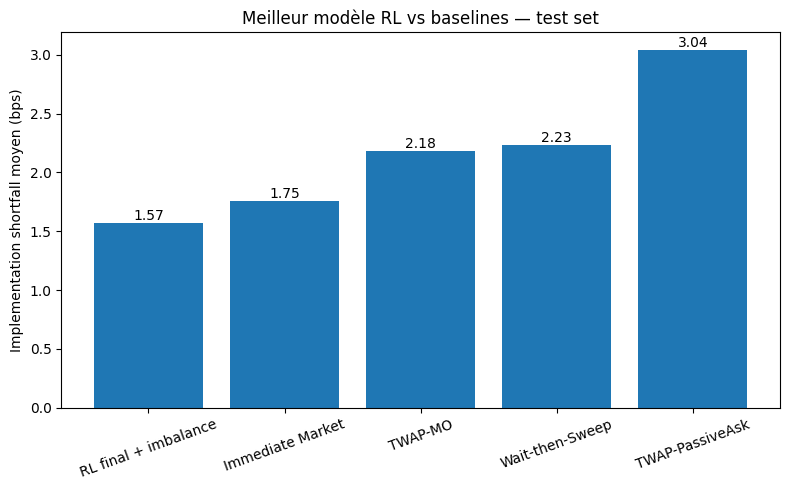

In [17]:
if not final_results_df.empty and final_results_df["mean_bps"].notna().any():
    plt.figure(figsize=(8, 5))
    bars = plt.bar(final_results_df["strategy"], final_results_df["mean_bps"])
    plt.ylabel("Implementation shortfall moyen (bps)")
    plt.title("Meilleur modèle RL vs baselines — test set")

    for bar, val in zip(bars, final_results_df["mean_bps"]):
        if pd.notna(val):
            plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}",
                     ha="center", va="bottom")

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("rl_best_model_results.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Aucune figure de comparaison : pas de résultats exploitables.")

## Heatmap de la politique du meilleur modèle

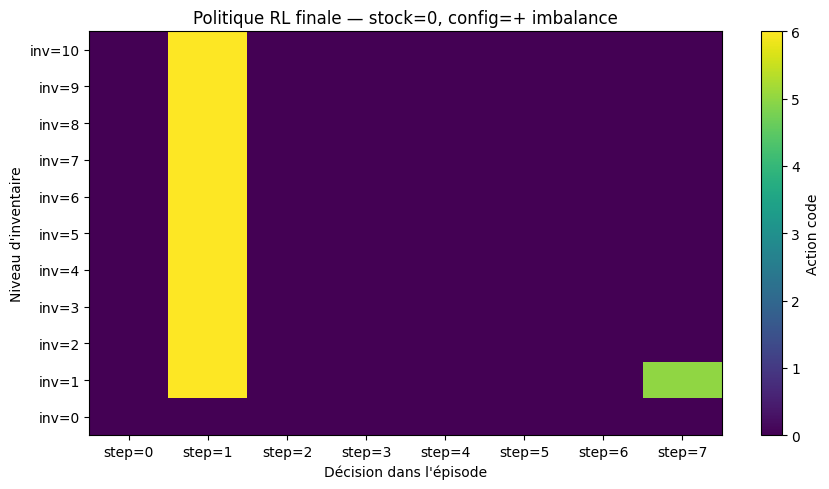

In [18]:
if BEST_Q_TABLES is None:
    print("Aucune heatmap : meilleur modèle indisponible.")
else:
    STOCK_TO_PLOT = 0

    # Valeurs par défaut pour les dimensions de marché absentes/presentes.
    default_disc_values = {}
    for feat in ["spread_disc", "imb_disc", "ret_disc"]:
        if feat in ob.columns and not ob[feat].empty:
            try:
                default_disc_values[feat] = int(ob[feat].mode(dropna=True).iloc[0])
            except Exception:
                default_disc_values[feat] = 1
        else:
            default_disc_values[feat] = 1

    policy_grid = np.full((I_LEVELS + 1, T_STEPS), np.nan)

    for inv_lvl in range(I_LEVELS + 1):
        for step_idx in range(T_STEPS):
            t_rem = T_STEPS - step_idx

            dummy_snapshot = pd.Series(default_disc_values)
            state = state_key(STOCK_TO_PLOT, inv_lvl, dummy_snapshot, BEST_STATE_FEATURES)

            best_action = None
            best_q = np.inf
            for action in ACTIONS:
                q_val, _ = lookup_q_mean(BEST_Q_TABLES[t_rem], state, action)
                if q_val is not None and q_val < best_q:
                    best_q = q_val
                    best_action = action

            if best_action is not None:
                action_code = {
                    "WAIT": 0,
                    "ASK_25": 1,
                    "ASK_50": 2,
                    "ASK_100": 3,
                    "MO_25": 4,
                    "MO_50": 5,
                    "MO_100": 6,
                }[best_action]
                policy_grid[inv_lvl, step_idx] = action_code

    if np.isfinite(policy_grid).any():
        plt.figure(figsize=(9, 5))
        im = plt.imshow(policy_grid, aspect="auto", origin="lower")
        plt.colorbar(im, label="Action code")
        plt.xticks(range(T_STEPS), [f"step={s}" for s in range(T_STEPS)])
        plt.yticks(range(I_LEVELS + 1), [f"inv={i}" for i in range(I_LEVELS + 1)])
        plt.xlabel("Décision dans l'épisode")
        plt.ylabel("Niveau d'inventaire")
        plt.title(
            f"Politique RL finale — stock={STOCK_TO_PLOT}, config={BEST_STATE_LABEL}"
        )
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune heatmap : pas de politique estimable.")

Best model           : + imbalance
State features       : ['imb_disc']
Stock visualisé      : 0
Buckets imb affichés : [0, 1, 2]


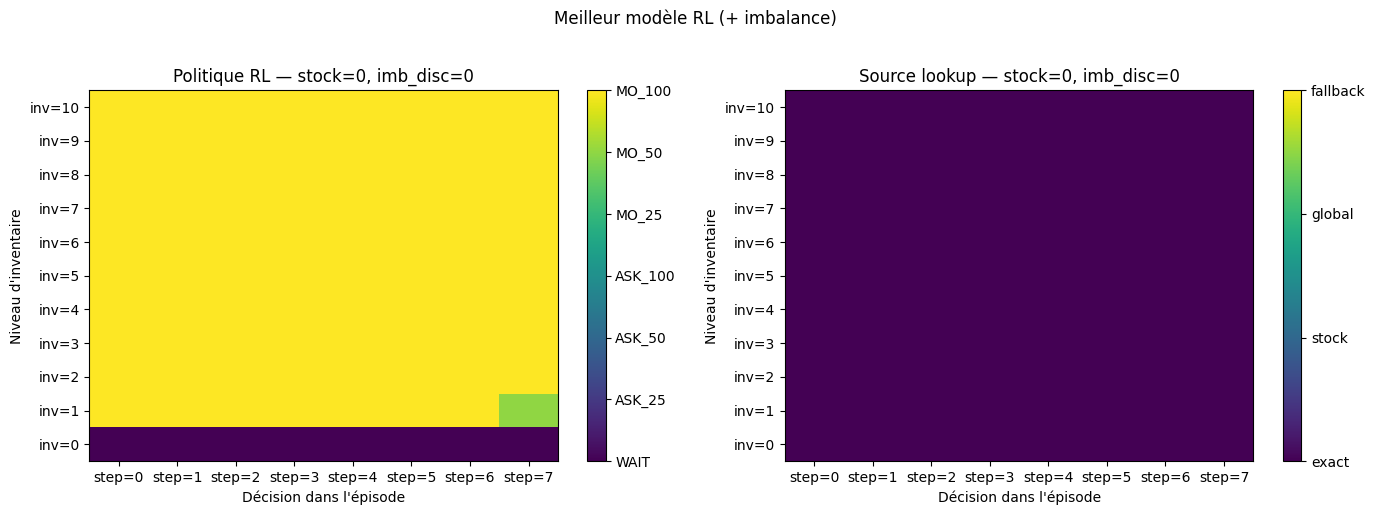

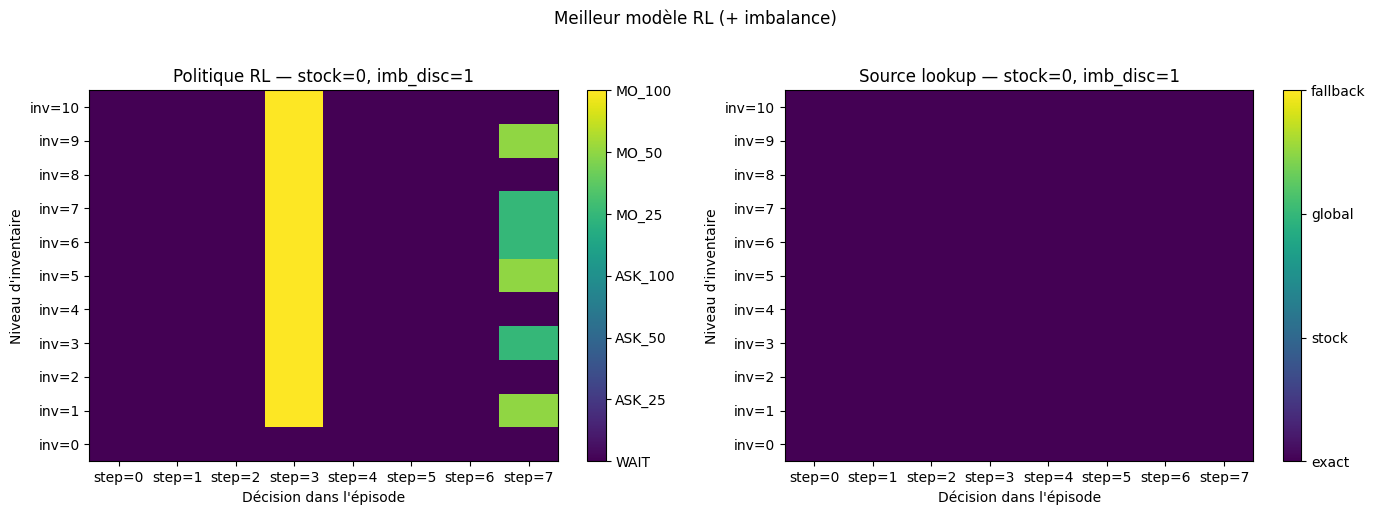

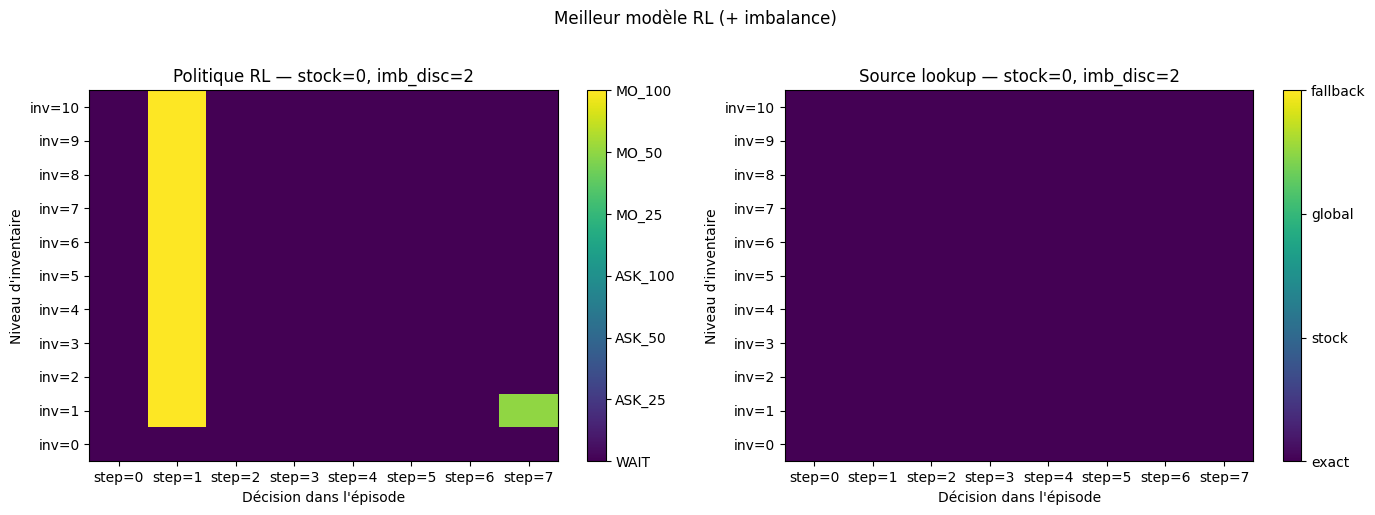

,imb_disc,source,count
0,0,exact,88
1,1,exact,88
2,2,exact,88



════════════════════════════════════════════════════════════════════════
TEST STATISTIQUE RL vs IMMEDIATE MARKET
Convention : diff = cost(Immediate) - cost(RL)
Donc diff > 0  => RL meilleur
════════════════════════════════════════════════════════════════════════
N épisodes                : 762
Gain moyen RL (bps)       : 0.1887
Gain médian RL (bps)      : 0.0000
Écart-type du gain        : 5.0018
% épisodes RL meilleur    : 33.60%
% épisodes égalité        :  39.63%
IC bootstrap 95% du gain  : [-0.1587, 0.5469] bps
Paired t-test p-value     : 0.149055
Wilcoxon signed-rank p    : 0.050901


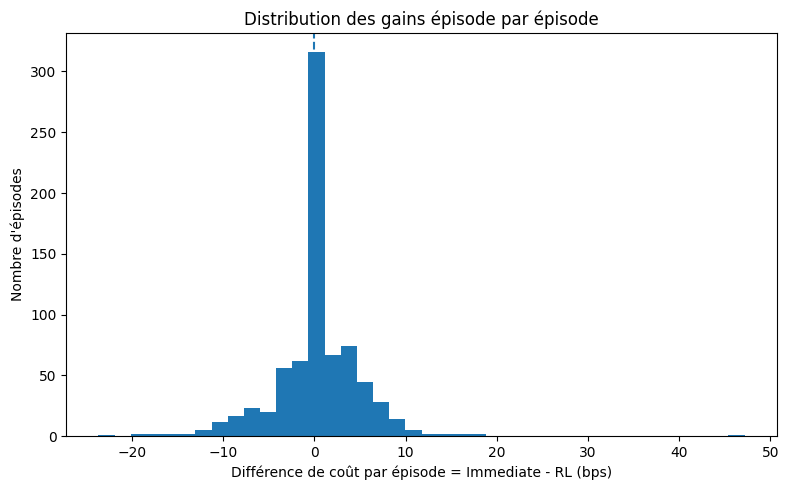

In [21]:
# %%
"""
## Visualisations détaillées du meilleur modèle
- heatmap de politique par imb_disc
- heatmap de la source de lookup (exact / stock / global / fallback)
- test statistique RL vs Immediate Market
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Vérifications minimales
# ------------------------------------------------------------
required_vars = [
    "BEST_Q_TABLES", "BEST_STATE_LABEL", "BEST_STATE_FEATURES",
    "res_rl_best", "res_immediate", "ob",
    "I_LEVELS", "T_STEPS", "ACTIONS",
    "state_key", "lookup_q_mean"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Variables manquantes dans le notebook: {missing}")

if BEST_Q_TABLES is None:
    raise RuntimeError("BEST_Q_TABLES est None : aucun meilleur modèle disponible.")

# ------------------------------------------------------------
# Paramètres d'affichage
# ------------------------------------------------------------
STOCK_TO_PLOT = 0

action_code_map = {
    "WAIT": 0,
    "ASK_25": 1,
    "ASK_50": 2,
    "ASK_100": 3,
    "MO_25": 4,
    "MO_50": 5,
    "MO_100": 6,
}
action_labels = list(action_code_map.keys())

source_code_map = {
    "exact": 0,
    "stock": 1,
    "global": 2,
    "fallback": 3,
}
source_labels = ["exact", "stock", "global", "fallback"]

# ------------------------------------------------------------
# Valeurs discrètes par défaut pour les features non affichées
# ------------------------------------------------------------
default_disc_values = {}
for feat in ["spread_disc", "imb_disc", "ret_disc"]:
    if feat in ob.columns and ob[feat].notna().any():
        try:
            default_disc_values[feat] = int(ob[feat].mode(dropna=True).iloc[0])
        except Exception:
            default_disc_values[feat] = 0
    else:
        default_disc_values[feat] = 0

# Si le meilleur modèle utilise imb_disc, on affiche une heatmap par bucket.
# Sinon, on affiche une seule tranche "par défaut".
if "imb_disc" in BEST_STATE_FEATURES and "imb_disc" in ob.columns:
    imb_values = sorted(pd.Series(ob["imb_disc"].dropna().unique()).astype(int).tolist())
else:
    imb_values = [default_disc_values.get("imb_disc", 0)]

print(f"Best model           : {BEST_STATE_LABEL}")
print(f"State features       : {BEST_STATE_FEATURES}")
print(f"Stock visualisé      : {STOCK_TO_PLOT}")
print(f"Buckets imb affichés : {imb_values}")

# ------------------------------------------------------------
# Construction des heatmaps
# ------------------------------------------------------------
for imb_val in imb_values:
    policy_grid = np.full((I_LEVELS + 1, T_STEPS), np.nan)
    source_grid = np.full((I_LEVELS + 1, T_STEPS), np.nan)

    for inv_lvl in range(I_LEVELS + 1):
        for step_idx in range(T_STEPS):
            t_rem = T_STEPS - step_idx

            snap_dict = default_disc_values.copy()
            snap_dict["imb_disc"] = int(imb_val)
            dummy_snapshot = pd.Series(snap_dict)

            state = state_key(STOCK_TO_PLOT, inv_lvl, dummy_snapshot, BEST_STATE_FEATURES)

            best_action = None
            best_q = np.inf
            best_source = "fallback"

            for action in ACTIONS:
                q_val, source = lookup_q_mean(BEST_Q_TABLES[t_rem], state, action)
                if q_val is not None and q_val < best_q:
                    best_q = q_val
                    best_action = action
                    best_source = source

            if best_action is not None:
                policy_grid[inv_lvl, step_idx] = action_code_map[best_action]
                source_grid[inv_lvl, step_idx] = source_code_map.get(best_source, source_code_map["fallback"])
            else:
                # état trop rare, aucun lookup exploitable
                policy_grid[inv_lvl, step_idx] = np.nan
                source_grid[inv_lvl, step_idx] = source_code_map["fallback"]

    # Affichage côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Heatmap politique
    im0 = axes[0].imshow(
        policy_grid,
        aspect="auto",
        origin="lower",
        vmin=min(action_code_map.values()),
        vmax=max(action_code_map.values()),
    )
    cbar0 = plt.colorbar(im0, ax=axes[0], ticks=list(action_code_map.values()))
    cbar0.ax.set_yticklabels(action_labels)
    axes[0].set_xticks(range(T_STEPS), [f"step={s}" for s in range(T_STEPS)])
    axes[0].set_yticks(range(I_LEVELS + 1), [f"inv={i}" for i in range(I_LEVELS + 1)])
    axes[0].set_xlabel("Décision dans l'épisode")
    axes[0].set_ylabel("Niveau d'inventaire")
    axes[0].set_title(
        f"Politique RL — stock={STOCK_TO_PLOT}, imb_disc={imb_val}"
    )

    # Heatmap source de lookup
    im1 = axes[1].imshow(
        source_grid,
        aspect="auto",
        origin="lower",
        vmin=min(source_code_map.values()),
        vmax=max(source_code_map.values()),
    )
    cbar1 = plt.colorbar(im1, ax=axes[1], ticks=list(source_code_map.values()))
    cbar1.ax.set_yticklabels(source_labels)
    axes[1].set_xticks(range(T_STEPS), [f"step={s}" for s in range(T_STEPS)])
    axes[1].set_yticks(range(I_LEVELS + 1), [f"inv={i}" for i in range(I_LEVELS + 1)])
    axes[1].set_xlabel("Décision dans l'épisode")
    axes[1].set_ylabel("Niveau d'inventaire")
    axes[1].set_title(
        f"Source lookup — stock={STOCK_TO_PLOT}, imb_disc={imb_val}"
    )

    plt.suptitle(f"Meilleur modèle RL ({BEST_STATE_LABEL})", y=1.02)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Résumé de la fréquence des sources de lookup sur les heatmaps
# ------------------------------------------------------------
summary_rows = []

for imb_val in imb_values:
    for inv_lvl in range(I_LEVELS + 1):
        for step_idx in range(T_STEPS):
            t_rem = T_STEPS - step_idx
            snap_dict = default_disc_values.copy()
            snap_dict["imb_disc"] = int(imb_val)
            dummy_snapshot = pd.Series(snap_dict)

            state = state_key(STOCK_TO_PLOT, inv_lvl, dummy_snapshot, BEST_STATE_FEATURES)

            best_action = None
            best_q = np.inf
            best_source = "fallback"

            for action in ACTIONS:
                q_val, source = lookup_q_mean(BEST_Q_TABLES[t_rem], state, action)
                if q_val is not None and q_val < best_q:
                    best_q = q_val
                    best_action = action
                    best_source = source

            summary_rows.append({
                "imb_disc": imb_val,
                "inv_lvl": inv_lvl,
                "step_idx": step_idx,
                "source": best_source,
                "action": best_action if best_action is not None else "NA",
            })

source_summary_df = pd.DataFrame(summary_rows)
display(
    source_summary_df.groupby(["imb_disc", "source"]).size()
    .rename("count")
    .reset_index()
    .sort_values(["imb_disc", "source"])
)

# ------------------------------------------------------------
# Test statistique RL vs Immediate Market
# ------------------------------------------------------------
rl_costs = np.asarray(res_rl_best["costs_bps"], dtype=float)
im_costs = np.asarray(res_immediate["costs_bps"], dtype=float)

if len(rl_costs) == 0 or len(im_costs) == 0:
    print("Test statistique impossible : au moins une stratégie n'a aucun épisode.")
elif len(rl_costs) != len(im_costs):
    print("Test statistique impossible : tailles différentes entre RL et Immediate Market.")
else:
    diff = im_costs - rl_costs   # diff > 0 => RL meilleur
    mean_diff = float(np.mean(diff))
    median_diff = float(np.median(diff))
    std_diff = float(np.std(diff, ddof=1)) if len(diff) > 1 else np.nan

    print("\n" + "═" * 72)
    print("TEST STATISTIQUE RL vs IMMEDIATE MARKET")
    print("Convention : diff = cost(Immediate) - cost(RL)")
    print("Donc diff > 0  => RL meilleur")
    print("═" * 72)
    print(f"N épisodes                : {len(diff)}")
    print(f"Gain moyen RL (bps)       : {mean_diff:.4f}")
    print(f"Gain médian RL (bps)      : {median_diff:.4f}")
    print(f"Écart-type du gain        : {std_diff:.4f}")
    print(f"% épisodes RL meilleur    : {100*np.mean(diff > 0):.2f}%")
    print(f"% épisodes égalité        : {100*np.mean(np.isclose(diff, 0.0)): .2f}%")

    # IC bootstrap 95% sur le gain moyen
    rng = np.random.default_rng(123)
    n_boot = 10000
    boot_means = np.empty(n_boot, dtype=float)
    n = len(diff)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = diff[idx].mean()

    ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
    print(f"IC bootstrap 95% du gain  : [{ci_low:.4f}, {ci_high:.4f}] bps")

    # Tests avec scipy si disponible
    try:
        from scipy import stats

        t_res = stats.ttest_rel(im_costs, rl_costs, alternative="greater")
        print(f"Paired t-test p-value     : {t_res.pvalue:.6g}")

        # Wilcoxon peut échouer si trop d'égalités exactes
        try:
            w_res = stats.wilcoxon(im_costs, rl_costs, alternative="greater", zero_method="wilcox")
            print(f"Wilcoxon signed-rank p    : {w_res.pvalue:.6g}")
        except Exception as e:
            print(f"Wilcoxon non disponible   : {e}")

    except Exception:
        print("scipy non disponible : t-test / Wilcoxon non calculés.")

    # Histogramme des différences
    plt.figure(figsize=(8, 5))
    plt.hist(diff, bins=40)
    plt.axvline(0.0, linestyle="--")
    plt.xlabel("Différence de coût par épisode = Immediate - RL (bps)")
    plt.ylabel("Nombre d'épisodes")
    plt.title("Distribution des gains épisode par épisode")
    plt.tight_layout()
    plt.show()

## Tableau récapitulatif : ablation + final

In [19]:
summary_tables = {
    "ablation": ablation_df.copy(),
    "final_comparison": final_results_df.copy(),
}

display(summary_tables["ablation"].round(4))
display(summary_tables["final_comparison"].round(4))

,state_config,features,mean_bps,std_bps
2,+ imbalance,"(imb_disc,)",1.5661,5.1070
1,+ spread,"(spread_disc,)",1.6564,4.3271
0,stock + inv only,(),1.6935,5.8404
4,+ spread + imb + ret,"(spread_disc, imb_disc, ret_disc)",1.8797,10.3116
3,+ spread + imbalance,"(spread_disc, imb_disc)",2.1080,10.6093


,strategy,mean_bps,std_bps
0,RL final + imbalance,1.5661,5.1070
1,Immediate Market,1.7548,1.2853
2,TWAP-MO,2.1796,7.1240
4,Wait-then-Sweep,2.2297,11.4881
3,TWAP-PassiveAsk,3.0391,9.9545
